# XGBoost From Scratch (NumPy Only)

**XGBoost** (Extreme Gradient Boosting) is an ensemble method that builds many small decision trees **one after another**. Each new tree is trained to correct the mistakes (residuals) of all the trees built so far.

The idea of **boosting** is simple: instead of training one big, complex tree, we combine many small, "weak" trees. Each tree only nudges the prediction a little closer to the truth. To make sure no single tree dominates the final result, we scale every tree's contribution by a small **learning rate** (also called *shrinkage*).

The animation below shows this happening on our own dataset: as more boosting rounds (trees) are added, the model's predicted probability curve gradually fits the actual data points better.

![XGBoost boosting animation](images/xgboost.gif)


## 2. Load and Explore the Data

We start by loading the dataset and taking a quick look at its structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**About the dataset:** this is the Pima Indians Diabetes dataset. It has 8 numeric input features (e.g. `Glucose`, `BMI`, `Age`, ...) describing a patient, and one target column, `Outcome`.

`Outcome` only takes the values **0** (no diabetes) or **1** (diabetes), so this is a **binary classification** problem. There are no missing values (no `NaN`s), so we can move straight to modeling.

## 3. Select Features and Target

All columns except `Outcome` are used as input features. Since this is a classification problem, the target stays as raw 0/1 values — we will use a **logistic loss** (log loss) and turn raw model scores into probabilities with a sigmoid function.

In [5]:
feature_cols = [c for c in df.columns if c != 'Outcome']

X = df[feature_cols].values.astype(float)
y = df['Outcome'].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


## 4. Train/Test Split (Manual)

We shuffle the row indices ourselves with NumPy and slice out 80% for training and 20% for testing — no `train_test_split`.

In [6]:
np.random.seed(42)
shuffled_idx = np.random.permutation(len(X))

split_point = int(0.8 * len(X))
train_idx, test_idx = shuffled_idx[:split_point], shuffled_idx[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 614 | Test size: 154


## 5. Feature Scaling

Tree-based models like XGBoost split on raw thresholds (e.g. `Glucose <= 127.5`), so, unlike distance-based models such as SVM or KNN, they **don't require feature scaling**. We can safely skip standardization and use the raw feature values.

## 6. The Math Behind XGBoost

- **Base prediction:** the model starts with one simple guess for everyone — the log-odds of the average outcome in the training data.
- **Gradients & Hessians:** at every round we measure how wrong the current predictions are. For log loss, the **gradient** is `g = p - y` (predicted probability minus actual label) and the **hessian** is `h = p * (1 - p)`.
- **Building a tree with Gain:** each new tree is a small regression tree trained on these gradients/hessians. A split is chosen by maximizing the **Gain**, which measures how much that split reduces the loss:

$$Gain = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]$$

  where $G$, $H$ are the summed gradients/hessians in a node, and $\lambda$ is a regularization term that keeps the tree from overfitting.
- **Leaf weights:** once a tree's shape is fixed, each leaf's output is $w = -\dfrac{G}{H+\lambda}$, computed from the gradients/hessians of the samples that land in that leaf.
- **Shrinkage (learning rate):** every tree's output is multiplied by a small learning rate before being added to the running prediction, so the ensemble improves gradually.
- **Boosting rounds:** repeat — compute gradients from the current predictions, fit a new tree to them, add its shrunk output to the running total.

## 7. XGBoost From Scratch

### 7.1 Sigmoid function
Converts a raw model score into a probability between 0 and 1.

In [7]:
def sigmoid(x):
    # clip to avoid overflow in exp()
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

### 7.2 Tree node and tree-building function

`TreeNode` is a simple container for one node of a tree (either a leaf with a value, or a split with a feature/threshold and two children).

`build_tree` grows the tree recursively: for every feature and every possible threshold, it computes the Gain of splitting there, and keeps the best split found (exact greedy search over sorted values). If no split improves the Gain, the node becomes a leaf.

In [8]:
class TreeNode:
    def __init__(self):
        self.is_leaf = True
        self.value = 0.0          # leaf weight (only used if is_leaf)
        self.feature_index = None
        self.threshold = None
        self.left = None
        self.right = None


def leaf_weight(grad, hess, lambda_):
    # Optimal leaf value: w = -G / (H + lambda)
    return -grad.sum() / (hess.sum() + lambda_)


def build_tree(X, grad, hess, depth, max_depth, lambda_, min_samples=10):
    node = TreeNode()
    G, H = grad.sum(), hess.sum()
    node.value = leaf_weight(grad, hess, lambda_)

    # Stop growing if max depth reached or too few samples
    if depth >= max_depth or len(X) < min_samples:
        return node

    best_gain = 0.0
    best_feature, best_threshold = None, None

    # Exact greedy search: try every feature, every sorted threshold
    for f in range(X.shape[1]):
        order = np.argsort(X[:, f])
        vals_sorted = X[order, f]
        grad_cum = np.cumsum(grad[order])
        hess_cum = np.cumsum(hess[order])

        for i in range(1, len(vals_sorted)):
            if vals_sorted[i] == vals_sorted[i - 1]:
                continue  # skip identical values (no valid split point)

            GL, HL = grad_cum[i - 1], hess_cum[i - 1]
            GR, HR = G - GL, H - HL

            gain = 0.5 * (GL**2 / (HL + lambda_) +
                          GR**2 / (HR + lambda_) -
                          G**2 / (H + lambda_))

            if gain > best_gain:
                best_gain = gain
                best_feature = f
                best_threshold = (vals_sorted[i] + vals_sorted[i - 1]) / 2

    # No split improves the loss -> keep this node as a leaf
    if best_feature is None:
        return node

    node.is_leaf = False
    node.feature_index = best_feature
    node.threshold = best_threshold

    left_mask = X[:, best_feature] <= best_threshold
    right_mask = ~left_mask

    node.left = build_tree(X[left_mask], grad[left_mask], hess[left_mask],
                            depth + 1, max_depth, lambda_, min_samples)
    node.right = build_tree(X[right_mask], grad[right_mask], hess[right_mask],
                             depth + 1, max_depth, lambda_, min_samples)
    return node


def predict_tree(node, X):
    # Walk down the tree for every row and return the leaf value
    preds = np.empty(len(X))
    for i, x in enumerate(X):
        cur = node
        while not cur.is_leaf:
            cur = cur.left if x[cur.feature_index] <= cur.threshold else cur.right
        preds[i] = cur.value
    return preds

### 7.3 The XGBoostScratch class

Ties everything together: it keeps a list of trees, and at every boosting round it computes fresh gradients/hessians from the current predictions, fits one new tree to them, and adds the tree's shrunk output to the running prediction.

In [9]:
class XGBoostScratch:
    def __init__(self, n_estimators=30, max_depth=3, learning_rate=0.3, lambda_=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.lr = learning_rate
        self.lambda_ = lambda_
        self.trees = []
        self.losses = []
        self.base_score = 0.0

    def fit(self, X, y):
        # Base prediction: log-odds of the mean outcome
        mean_y = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.base_score = np.log(mean_y / (1 - mean_y))

        pred = np.full(len(y), self.base_score)  # running raw score

        for _ in range(self.n_estimators):
            p = sigmoid(pred)
            grad = p - y            # gradient of log loss
            hess = p * (1 - p)      # hessian of log loss

            tree = build_tree(X, grad, hess, depth=0,
                               max_depth=self.max_depth, lambda_=self.lambda_)
            update = predict_tree(tree, X)

            pred = pred + self.lr * update   # shrinkage applied here
            self.trees.append(tree)

            # track training log loss
            p_clipped = np.clip(sigmoid(pred), 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(p_clipped) + (1 - y) * np.log(1 - p_clipped))
            self.losses.append(loss)

    def predict_proba(self, X):
        pred = np.full(len(X), self.base_score)
        for tree in self.trees:
            pred = pred + self.lr * predict_tree(tree, X)
        return sigmoid(pred)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## 8. Training the Model

We train on `X_train`/`y_train` for a fixed number of boosting rounds, using simple, reasonable defaults. During training, every new tree fits the gradients of the current errors, so the training loss should generally keep decreasing as more trees are added.

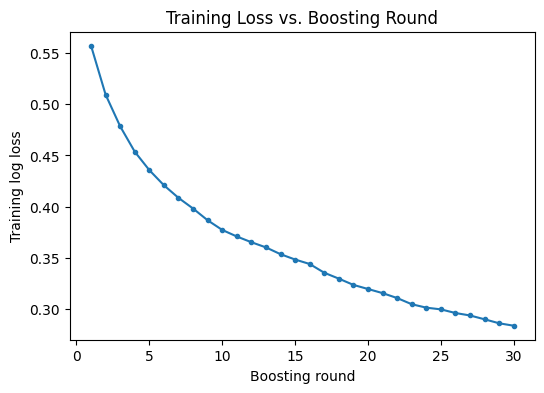

In [10]:
model = XGBoostScratch(n_estimators=30, max_depth=3, learning_rate=0.3, lambda_=1.0)
model.fit(X_train, y_train)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model.losses) + 1), model.losses, marker='o', markersize=3)
plt.xlabel('Boosting round')
plt.ylabel('Training log loss')
plt.title('Training Loss vs. Boosting Round')
plt.show()

## 9. Making Predictions

The final prediction is the **base score plus every tree's shrunk output, summed together**. This raw score is turned into a probability with the sigmoid function, and then into a class label using a 0.5 threshold.

In [11]:
test_probs = model.predict_proba(X_test)
test_preds = model.predict(X_test)

print("Example predicted probabilities:", np.round(test_probs[:10], 3))
print("Example predicted labels:      ", test_preds[:10].astype(int))
print("Example actual labels:         ", y_test[:10].astype(int))

Example predicted probabilities: [0.05  0.063 0.617 0.515 0.647 0.536 0.213 0.117 0.116 0.253]
Example predicted labels:       [0 0 1 1 1 1 0 0 0 0]
Example actual labels:          [0 0 0 0 1 0 0 0 1 0]


## 10. Model Evaluation

Since this is classification, we compute **accuracy** manually, plus a simple confusion matrix (TP, TN, FP, FN).

In [12]:
accuracy = np.mean(test_preds == y_test)

TP = np.sum((test_preds == 1) & (y_test == 1))
TN = np.sum((test_preds == 0) & (y_test == 0))
FP = np.sum((test_preds == 1) & (y_test == 0))
FN = np.sum((test_preds == 0) & (y_test == 1))

print(f"Accuracy: {accuracy:.3f}")
print(f"TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}")

Accuracy: 0.773
TP: 36  TN: 83  FP: 13  FN: 22


## 11. Visualizing Model Improvement

As a final check, we compare the predicted probabilities on the test set against the actual outcomes. Points near the top-right (high probability, actual 1) and bottom-left (low probability, actual 0) mean the model is doing well.

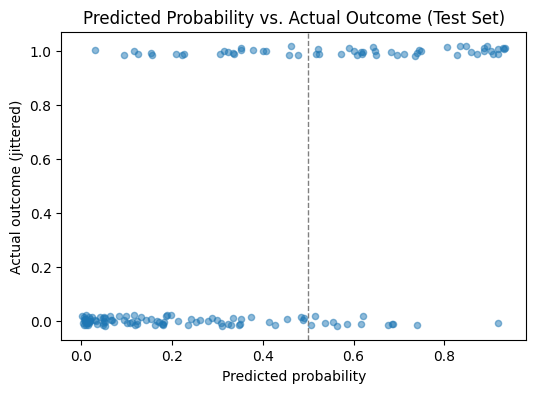

In [13]:
plt.figure(figsize=(6, 4))
jitter = np.random.uniform(-0.02, 0.02, size=len(y_test))
plt.scatter(test_probs, y_test + jitter, alpha=0.5, s=20)
plt.xlabel('Predicted probability')
plt.ylabel('Actual outcome (jittered)')
plt.title('Predicted Probability vs. Actual Outcome (Test Set)')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.show()

## 12. Conclusion

- **XGBoost** builds many small trees one after another, where each tree corrects the errors of the trees before it — this is called **boosting**.
- At every round we compute **gradients** and **hessians**, which tell each new tree how wrong the current predictions are and how confident to be about fixing them.
- Trees are grown by picking splits that maximize **Gain**, using a regularization term ($\lambda$) to keep leaf weights small and avoid overfitting.
- **Shrinkage** (the learning rate) scales down every tree's contribution so the model learns gradually instead of overfitting to any single tree.
- The final prediction is simply the **base score plus the shrunk output of every tree, added together**, then passed through a sigmoid to get a probability.
